In [43]:
import importlib.util
import sys
import subprocess

In [44]:
req_lib=['pandas','numpy','matplotlib','seaborn']
missing_lib=[lib for lib in req_lib if importlib.util.find_spec(lib) is None]

In [45]:
if missing_lib:
  print('missing lib',missing_lib)
  subprocess.check_call([sys.executable,'-m','pip','install','--quit',*missing_lib])
else:
  print('all lib installed')

all lib installed


In [9]:
from pathlib import Path
PROJECT_ROOT=Path.cwd()
RAW_DATA_DIR=PROJECT_ROOT/'data'/'raw'
PROCESSED_DATA_DIR=PROJECT_ROOT/'data'/'processed'

for dir in [RAW_DATA_DIR,PROCESSED_DATA_DIR]:
  dir.mkdir(parents=True,exist_ok=True)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
raw_data_path = RAW_DATA_DIR / "penguins.csv"
raw_data_path.parent.mkdir(parents=True, exist_ok=True)

In [12]:
df=pd.read_csv(raw_data_path)

In [13]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [14]:
print(type(df))

<class 'pandas.DataFrame'>


In [15]:
df.sample(5, random_state=42)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
194,Chinstrap,Dream,50.9,19.1,196.0,3550.0,MALE
157,Chinstrap,Dream,45.2,17.8,198.0,3950.0,FEMALE
225,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,FEMALE
208,Chinstrap,Dream,45.2,16.6,191.0,3250.0,FEMALE
318,Gentoo,Biscoe,48.4,14.4,203.0,4625.0,FEMALE


In [16]:
df.shape

(344, 7)

In [17]:
df.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


- 1-What does one row represent?
    - One row represents one penguin.
- 2-Which columns are numerical and which are categorical?
    - Numerical: bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g
    - Categorical: species, island, sex
- 3-If species were predicted later, what would the target be?
    - The target would be the valuse of column.
- 4-What is one thing you noticed before doing any cleaning?
    - There are missing values in some columns.

In [20]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [21]:
missing_rows = df[df.isnull().any(axis=1)]
display(missing_rows.index)

Index([3, 8, 9, 10, 11, 47, 246, 286, 324, 336, 339], dtype='int64')

In [22]:
missing_per=df.isnull().sum()/df.shape[0]*100
missing_per

species              0.000000
island               0.000000
bill_length_mm       0.581395
bill_depth_mm        0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  3.197674
dtype: float64

In [23]:
display(missing_rows)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


- 1. Which columns contain missing values?
    - 3,8,9,10,11,47,246,324,336,339

In [24]:
df = df.drop(index=[3, 339])
df.shape

(342, 7)

In [25]:
df.duplicated().sum()

np.int64(0)

- 2. Are there duplicate rows? What would you verify before deleting them?


---


    - no

In [26]:
df.nunique(dropna=False)


species                3
island                 3
bill_length_mm       164
bill_depth_mm         80
flipper_length_mm     55
body_mass_g           94
sex                    3
dtype: int64

In [27]:
for column in df.columns:
    print(f"Value counts for '{column}':")
    display(df[column].value_counts())
    print("\n" + "-"*30 + "\n")

Value counts for 'species':


species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64


------------------------------

Value counts for 'island':


island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64


------------------------------

Value counts for 'bill_length_mm':


...


------------------------------

Value counts for 'body_mass_g':


body_mass_g
3800.0    12
3700.0    11
3950.0    10
3900.0    10
3550.0     9
          ..
5450.0     1
4975.0     1
4575.0     1
4375.0     1
5750.0     1
Name: count, Length: 94, dtype: int64


------------------------------

Value counts for 'sex':


sex
MALE      168
FEMALE    165
Name: count, dtype: int64


------------------------------



- 3. Which columns have low cardinality, and what does that tell you about them?


---

    - sex,island,species

In [28]:
num_clolumns=df.select_dtypes(include=np.number).columns
num_clolumns

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='str')

In [29]:
cat_columns=df.select_dtypes(exclude=np.number).columns
cat_columns

Index(['species', 'island', 'sex'], dtype='str')

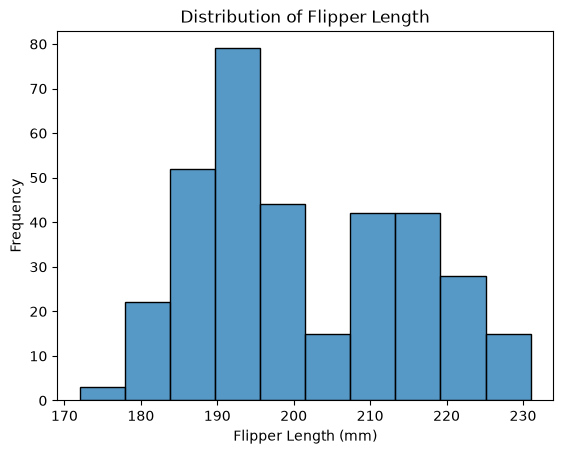

In [30]:
sns.histplot(df["flipper_length_mm"].dropna())
plt.title("Distribution of Flipper Length")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Frequency")
plt.show()

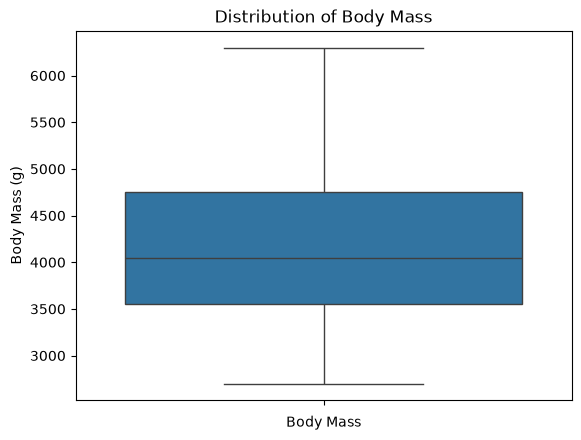

In [31]:
sns.boxplot(y=df["body_mass_g"])
plt.title("Distribution of Body Mass")
plt.xlabel("Body Mass")
plt.ylabel("Body Mass (g)")
plt.show()

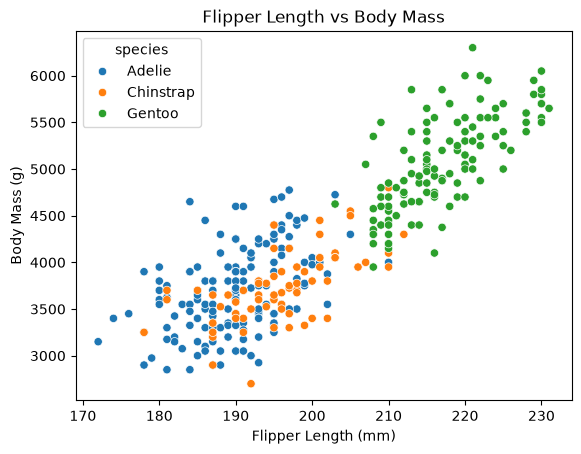

In [32]:
sns.scatterplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species"
)
plt.title("Flipper Length vs Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

In [33]:
q1 = df["body_mass_g"].dropna().quantile(0.25)
q3 = df["body_mass_g"].dropna().quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr


In [34]:
lower_bound

np.float64(1750.0)

In [35]:
upper_bound

np.float64(6550.0)

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


-- no outliers

In [37]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [38]:
df_mean_body_mass = df.groupby('species')['body_mass_g'].mean()
display(df_mean_body_mass)

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

- Adelie and Chinstrap have similar average body masses, while Gentoo has a different average body mass.

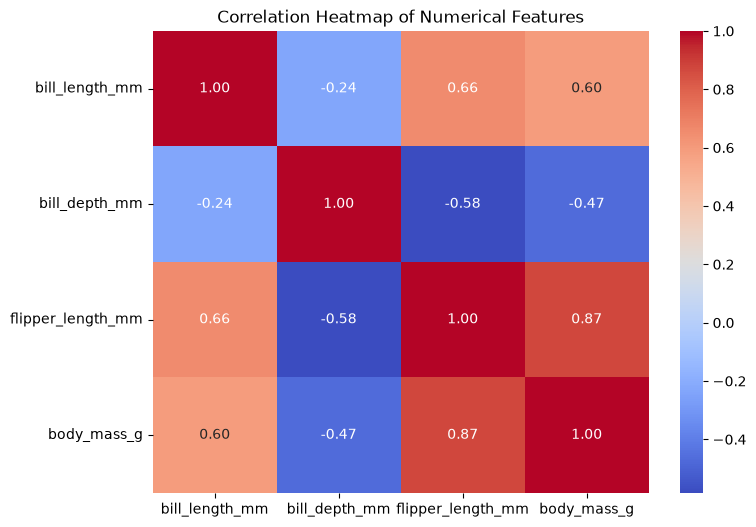

In [39]:
correlation_matrix = df[num_clolumns].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

- yes they are related with positive relation ship

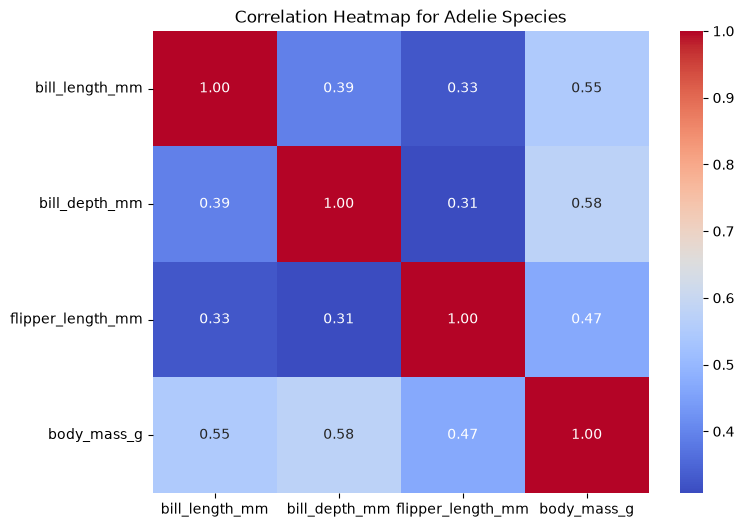


------------------------------



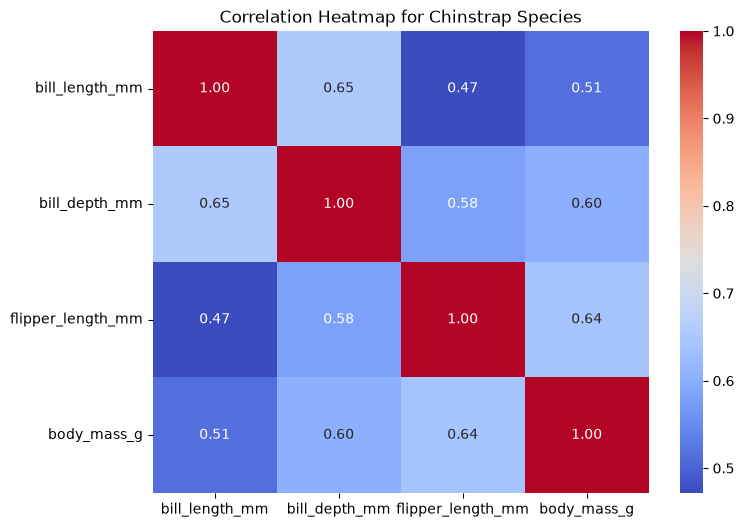


------------------------------



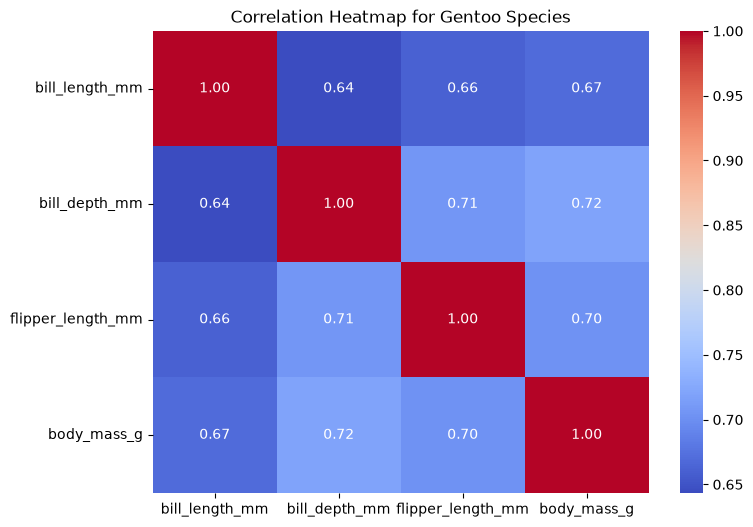


------------------------------



In [40]:
for species_name in df['species'].unique():
    df_species = df[df['species'] == species_name][num_clolumns]
    correlation_matrix_species = df_species.corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix_species, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Heatmap for {species_name} Species')
    plt.show()
    print("\n" + "-"*30 + "\n")

- Does that relationship look different across species?

    - Yes, the relationship between flipper length and body mass differs across species. Gentoo penguins generally have longer flippers and higher body mass, while Adelie and Chinstrap show more overlap.

In [41]:
island_groubs=df.groupby('island')['species'].value_counts()
island_groubs

island     species  
Biscoe     Gentoo       123
           Adelie        44
Dream      Chinstrap     68
           Adelie        56
Torgersen  Adelie        51
Name: count, dtype: int64

- Biscoe has gentoo and adelie , dream has chinstrap and adelie , torgersen has only adelie


In [42]:
sex_group=df.groupby('sex')['body_mass_g'].mean()
sex_group
#hello

sex
FEMALE    3862.272727
MALE      4545.684524
Name: body_mass_g, dtype: float64

- yes they have deffirant

- What was the most important data-quality issue you found?
  - missing values

- Which question produced the most useful insight, and why?

  - The most useful insight was that penguin body measurements differ across islands and between males and females.

-  What would you verify before using this dataset to train a real model?
  - missing values,encoding,handle outliers